In [3]:
!pip install yfinance

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import scipy.stats as stats

In [5]:
tickers = ['LMT', 'CL=F', 'TLT']

In [6]:
print("Downloading data...")
prices = yf.download(tickers, start='2024-03-05', end='2026-03-06')

/tmp/ipykernel_351/1473369813.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start='2024-03-05', end='2026-03-06')
[*********************100%***********************]  3 of 3 completed


In [7]:
returns = prices.pct_change().dropna()

/tmp/ipykernel_351/1620807809.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()


In [8]:
returns_y1 = returns.loc['2024-03-05':'2025-03-05']
returns_full = returns

print("\nFirst 5 rows of daily returns:")
print(returns.head())

print("\n--- Q1A: Normality Tests (Shapiro-Wilk) ---")
for asset in tickers:
    stat, p_value = stats.shapiro(returns_full['Close'][asset].dropna())
    print(f"\n{asset}:")
    print(f"Test Statistic: {stat:.4f}, P-value: {p_value:.4g}")
    if p_value < 0.05:
        print("Result: Reject the null hypothesis. The returns are NOT normally distributed.")
    else:
        print("Result: Fail to reject the null hypothesis. The returns ARE normally distributed.")

def calculate_historical_risk(data_series):
    clean_data = data_series.dropna()
    std_dev = clean_data.std()
    var_1 = np.percentile(clean_data, 1)
    es_1 = clean_data[clean_data <= var_1].mean()
    return std_dev, var_1, es_1

def calculate_parametric_risk(data_series):
    clean_data = data_series.dropna()
    mu = clean_data.mean()
    sigma = clean_data.std()
    var_1 = stats.norm.ppf(0.01, loc=mu, scale=sigma)
    z = stats.norm.ppf(0.01)
    pdf_z = stats.norm.pdf(z)
    es_1 = mu - sigma * (pdf_z / 0.01)
    return var_1, es_1

print("\n--- Q1B: Risk Metrics (First Year: Mar 2024 - Mar 2025) ---")
for asset in tickers:
    std, var, es = calculate_historical_risk(returns_y1['Close'][asset])
    print(f"{asset} -> 1-Day Std Dev: {std:.4f} | Historical VaR (1%): {var:.4f} | Historical ES (1%): {es:.4f}")

print("\n--- Q1C: Risk Metrics (Full 2 Years) ---")
for asset in tickers:
    std, var, es = calculate_historical_risk(returns_full['Close'][asset])
    print(f"{asset} -> 1-Day Std Dev: {std:.4f} | Historical VaR (1%): {var:.4f} | Historical ES (1%): {es:.4f}")

print("\n--- Q1D: Parametric Risk Metrics (Full 2 Years, Assuming Normal Distribution) ---")
for asset in tickers:
    var_param, es_param = calculate_parametric_risk(returns_full['Close'][asset])
    print(f"{asset} -> Parametric VaR (1%): {var_param:.4f} | Parametric ES (1%): {es_param:.4f}")


First 5 rows of daily returns:
Price          Close                          High                      \
Ticker          CL=F       LMT       TLT      CL=F       LMT       TLT   
Date                                                                     
2024-03-06  0.012540  0.003472  0.005868  0.014845 -0.005046  0.005121   
2024-03-07 -0.002527 -0.008051 -0.000938 -0.014132  0.004080  0.002392   
2024-03-08 -0.011656  0.006768 -0.001773  0.005784 -0.005969 -0.003631   
2024-03-11 -0.001026  0.004274 -0.000522 -0.019002  0.006998 -0.000417   
2024-03-12 -0.004748  0.000368 -0.008361  0.003313 -0.000527 -0.008332   

Price            Low                              Open                      \
Ticker          CL=F       LMT           TLT      CL=F       LMT       TLT   
Date                                                                         
2024-03-06  0.006063  0.002699  4.633091e-03 -0.007493 -0.004058  0.002730   
2024-03-07  0.000385 -0.003342  7.335622e-04  0.012540  0.00467

In [9]:
print("\n--- Extra bit of data for Q1A, skewness and kurtosis ---")
for asset in tickers:
    skew = returns_full['Close'][asset].skew()
    kurtosis = returns_full['Close'][asset].kurtosis()
    print(f"{asset} -> Skewness: {skew:.4f} | Excess Kurtosis: {kurtosis:.4f}")


--- Extra bit of data for Q1A, skewness and kurtosis ---
LMT -> Skewness: -1.3821 | Excess Kurtosis: 9.6623
CL=F -> Skewness: -0.0848 | Excess Kurtosis: 1.8795
TLT -> Skewness: -0.2113 | Excess Kurtosis: 0.9023


**So the data points I got back here seemed a bit odd to me, with some seemingly crazy figures. As such I decided to plot them visually, see the 5 worst days for each (to see whats causing the weird figures) and also to export the data into an excel file so I could manually review the data in case it was messed up.**


--- Top 5 Worst Drops for Each Asset ---

[LMT] Worst Days:
Date
2025-07-22   -0.108115
2025-01-28   -0.091802
2024-10-22   -0.061226
2025-03-21   -0.057934
2025-04-04   -0.049760
Name: LMT, dtype: float64


[CL=F] Worst Days:
Date
2025-06-23   -0.085680
2025-04-04   -0.074085
2025-04-03   -0.066378
2024-10-28   -0.061298
2025-06-24   -0.060429
Name: CL=F, dtype: float64


[TLT] Worst Days:
Date
2025-04-07   -0.030156
2025-04-10   -0.027568
2024-11-06   -0.027389
2024-08-06   -0.022368
2024-04-10   -0.021793
Name: TLT, dtype: float64


Successfully saved returns data to 'asset_returns.csv'



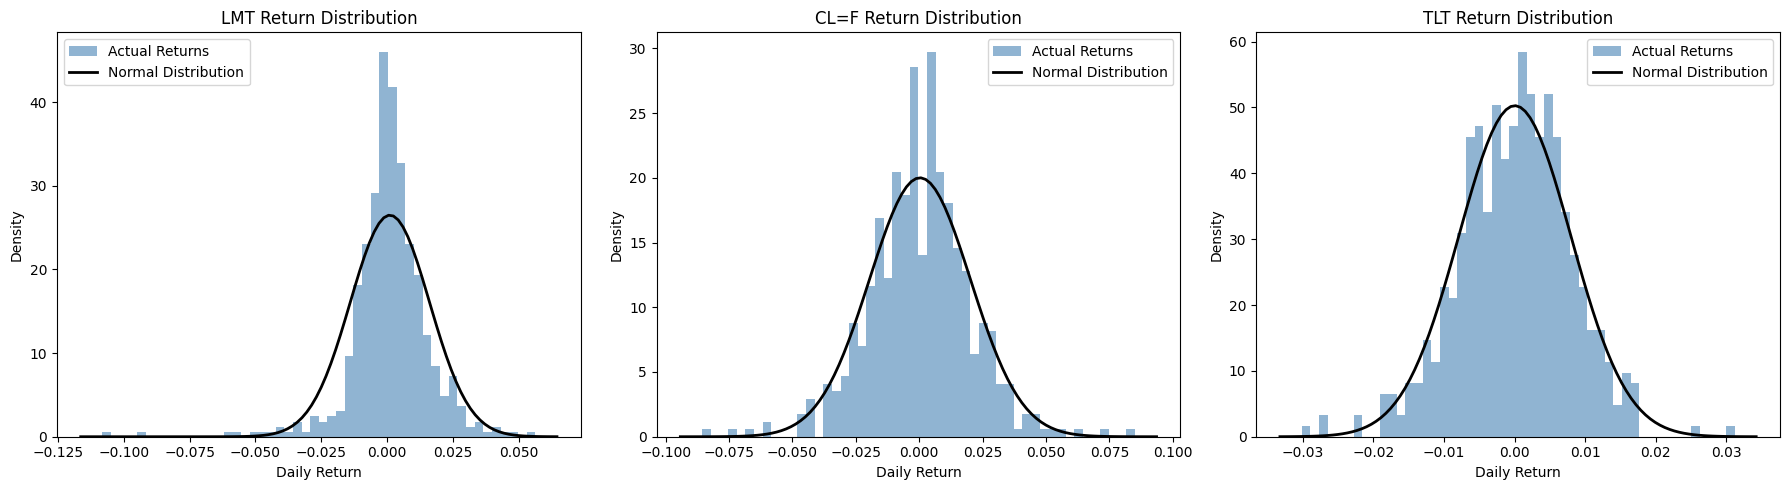

In [10]:
import matplotlib.pyplot as plt

print("--- Top 5 Worst Drops for Each Asset ---\n")
for asset in tickers:
    worst_days = returns_full['Close'][asset].sort_values().head(5)
    print(f"[{asset}] Worst Days:")
    print(worst_days)
    print("\n")

returns_full['Close'].to_csv('asset_returns.csv')
print("Successfully saved returns data to 'asset_returns.csv'\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, asset in enumerate(tickers):
    data = returns_full['Close'][asset].dropna()

    axes[i].hist(data, bins=50, density=True, alpha=0.6, color='steelblue', label='Actual Returns')

    mu, std = data.mean(), data.std()
    xmin, xmax = axes[i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[i].plot(x, p, 'k', linewidth=2, label='Normal Distribution')

    axes[i].set_title(f'{asset} Return Distribution')
    axes[i].set_xlabel('Daily Return')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

**I wanted to download this from Python to use for my report so I used AI to help me come up with the code for downloading this info.**


Successfully created Worst_5_Days.xlsx
Successfully created LMT_Return_Distribution.png


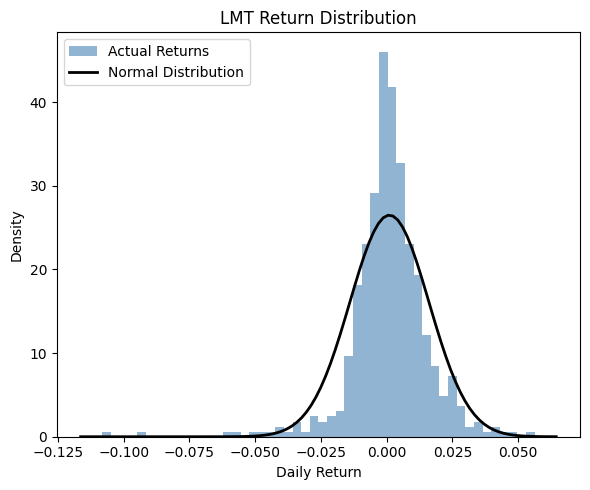

Successfully created CL=F_Return_Distribution.png


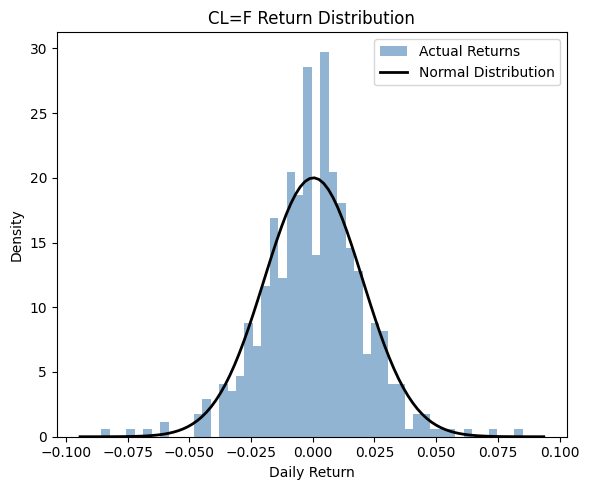

Successfully created TLT_Return_Distribution.png


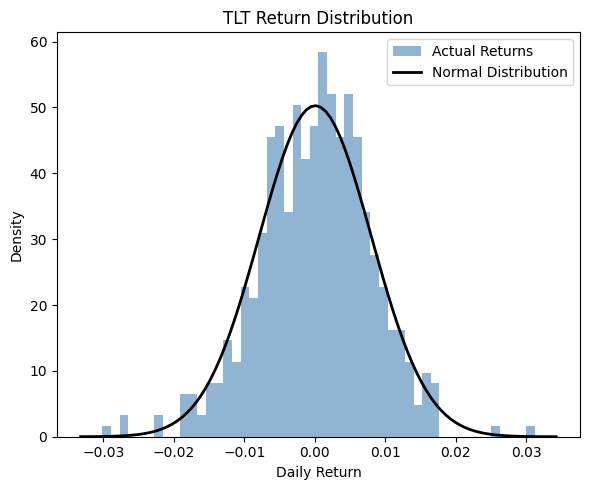

Triggering downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from google.colab import files

worst_days_list = []
for asset in tickers:
    worst = returns_full['Close'][asset].sort_values().head(5).reset_index()
    worst.columns = [f'{asset} Date', f'{asset} Return']
    worst_days_list.append(worst)

worst_days_df = pd.concat(worst_days_list, axis=1)

excel_filename = 'Worst_5_Days.xlsx'
worst_days_df.to_excel(excel_filename, index=False)
print(f"Successfully created {excel_filename}")

image_filenames = []

for asset in tickers:
    data = returns_full['Close'][asset].dropna()

    plt.figure(figsize=(6, 5))

    plt.hist(data, bins=50, density=True, alpha=0.6, color='steelblue', label='Actual Returns')

    mu, std = data.mean(), data.std()
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    plt.plot(x, p, 'k', linewidth=2, label='Normal Distribution')

    plt.title(f'{asset} Return Distribution')
    plt.xlabel('Daily Return')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()

    image_filename = f'{asset}_Return_Distribution.png'
    plt.savefig(image_filename)
    print(f"Successfully created {image_filename}")
    image_filenames.append(image_filename)

    plt.show()

print("Triggering downloads...")
files.download(excel_filename)
for filename in image_filenames:
    files.download(filename)

**Moving onto question 2 for now**


In [14]:
print("--- Q2: Equal-Weighted Portfolio Risk Metrics (Full 2 Years) ---\n")

weights = np.array([1/3, 1/3, 1/3])

portfolio_returns = returns_full['Close'][['LMT', 'CL=F', 'TLT']].dot(weights)

port_std = portfolio_returns.std()
port_var = np.percentile(portfolio_returns, 1)
port_es = portfolio_returns[portfolio_returns <= port_var].mean()

print(f"Portfolio 1-Day Std Dev: {port_std:.4f} (or {port_std*100:.2f}%)")
print(f"Portfolio Historical 1% VaR: {port_var:.4f} (or {port_var*100:.2f}%)")
print(f"Portfolio Historical 1% ES: {port_es:.4f} (or {port_es*100:.2f}%)")

--- Q2: Equal-Weighted Portfolio Risk Metrics (Full 2 Years) ---

Portfolio 1-Day Std Dev: 0.0087 (or 0.87%)
Portfolio Historical 1% VaR: -0.0255 (or -2.55%)
Portfolio Historical 1% ES: -0.0305 (or -3.05%)


**This next script is undeniably AI assisted, my knowledge of python was too limited, and so I enlisted the help of Gemini. I still did the general framework myself and gave the AI specific instructions, but the more complex lines of code are AI assisted.**

In [28]:
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

print("--- Q3: Hedging Jet Fuel with Crude Oil Futures ---\n")

try:
    eia = pd.read_excel('US EIA Data.xlsx', sheet_name='Data 1', skiprows=2)
except FileNotFoundError:
    print("❌ ERROR: Colab cannot find 'US EIA Data.xlsx'.")
    print("Please make sure your file is uploaded and named exactly 'US EIA Data.xlsx'")
    raise

eia = eia.iloc[:, [0, 1]].copy()
eia.columns = ['Date', 'Jet_Fuel_Price']

eia['Date'] = pd.to_datetime(eia['Date'], errors='coerce')
eia = eia.dropna(subset=['Date'])
eia.set_index('Date', inplace=True)
eia['Jet_Fuel_Price'] = pd.to_numeric(eia['Jet_Fuel_Price'], errors='coerce')

clf = yf.download('CL=F', start='2024-03-05', end='2026-03-03', auto_adjust=True)['Close']
if isinstance(clf, pd.DataFrame):
    clf = clf.squeeze()
clf.name = 'Crude_Oil_Price'

df = pd.merge(eia, clf, left_index=True, right_index=True, how='inner').dropna()

df_est = df.loc[:'2025-09-05']
df_test = df.loc['2025-09-05':]

delta_spot = df_est['Jet_Fuel_Price'].diff().dropna()
delta_futures = df_est['Crude_Oil_Price'].diff().dropna()
model_data = pd.concat([delta_spot, delta_futures], axis=1).dropna()

X = sm.add_constant(model_data['Crude_Oil_Price'])
Y = model_data['Jet_Fuel_Price']
model = sm.OLS(Y, X).fit()

h_star = model.params.iloc[1]
r_squared = model.rsquared

print(f"Optimal Hedge Ratio (h*): {h_star:.4f}")
print(f"Regression R-squared (Hedge Effectiveness): {r_squared:.4f}\n")

gallons_needed = 1000000
contract_size_barrels = 1000

num_contracts = (gallons_needed * h_star) / contract_size_barrels
contracts_rounded = round(num_contracts)

print(f"--- Contract Calculation ---")
print(f"Exact contracts needed: {num_contracts:.2f}")
print(f"Actual contracts to buy: {contracts_rounded}\n")

start_date = df_test.index[0]
end_date = df_test.index[-1]

spot_start = df.loc[start_date, 'Jet_Fuel_Price']
spot_end = df.loc[end_date, 'Jet_Fuel_Price']
fut_start = df.loc[start_date, 'Crude_Oil_Price']
fut_end = df.loc[end_date, 'Crude_Oil_Price']

print(f"--- Real-World Hedge Simulation ---")
print(f"Hedge initiated on: {start_date.date()}")
print(f"Fuel consumed on: {end_date.date()}\n")

unhedged_cost = gallons_needed * spot_end
print(f"1. Unhedged Scenario:")
print(f"   Cost to buy 1M gallons at market price (${spot_end:.2f}/gal): ${unhedged_cost:,.2f}\n")

futures_profit_loss = contracts_rounded * contract_size_barrels * (fut_end - fut_start)
net_hedged_cost = unhedged_cost - futures_profit_loss
effective_price = net_hedged_cost / gallons_needed

print(f"2. Hedged Scenario:")
print(f"   Profit/Loss from {contracts_rounded} Crude Oil Futures: ${futures_profit_loss:,.2f}")
print(f"   Net Total Cost of Fuel: ${net_hedged_cost:,.2f}")
print(f"   Effective Price per Gallon: ${effective_price:.4f}")

--- Q3: Hedging Jet Fuel with Crude Oil Futures ---



[*********************100%***********************]  1 of 1 completed

Optimal Hedge Ratio (h*): 0.0248
Regression R-squared (Hedge Effectiveness): 0.5887

--- Contract Calculation ---
Exact contracts needed: 24.79
Actual contracts to buy: 25

--- Real-World Hedge Simulation ---
Hedge initiated on: 2025-09-05
Fuel consumed on: 2026-03-02

1. Unhedged Scenario:
   Cost to buy 1M gallons at market price ($2.74/gal): $2,738,000.00

2. Hedged Scenario:
   Profit/Loss from 25 Crude Oil Futures: $234,000.11
   Net Total Cost of Fuel: $2,503,999.89
   Effective Price per Gallon: $2.5040


**I thought some visualisations of this data would be good, so I decided to create a line chart for the price co-movement, and a scatter plot to show the OLS regression**

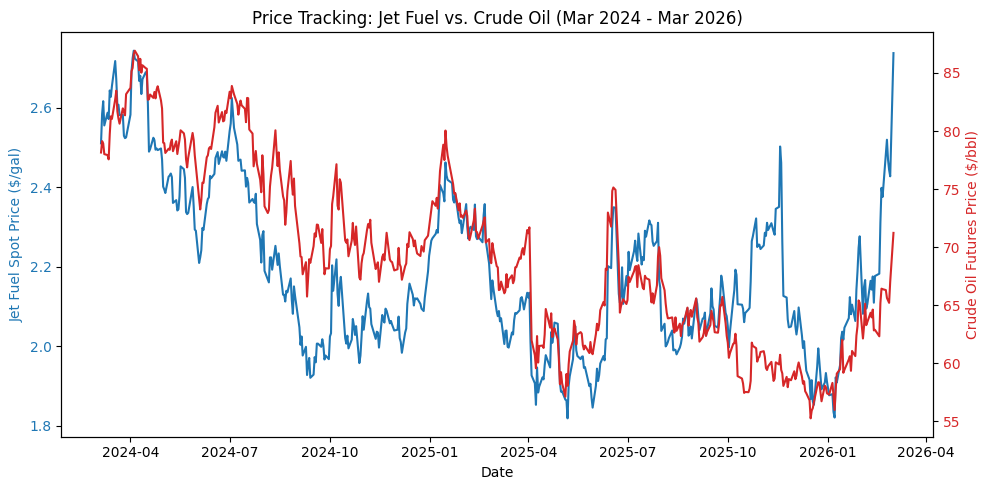

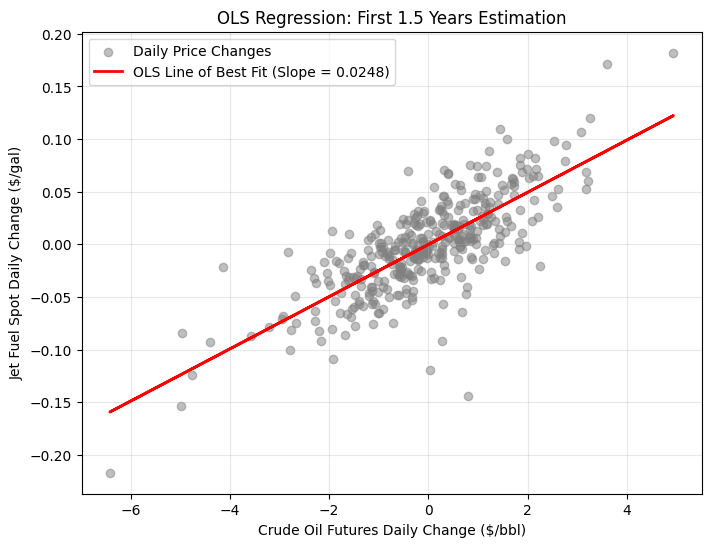

In [24]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Jet Fuel Spot Price ($/gal)', color=color)
ax1.plot(df.index, df['Jet_Fuel_Price'], color=color, label='Jet Fuel')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Crude Oil Futures Price ($/bbl)', color=color)
ax2.plot(df.index, df['Crude_Oil_Price'], color=color, label='Crude Oil (CL=F)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Price Tracking: Jet Fuel vs. Crude Oil (Mar 2024 - Mar 2026)')
fig.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(model_data['Crude_Oil_Price'], model_data['Jet_Fuel_Price'], alpha=0.5, color='gray', label='Daily Price Changes')

plt.plot(model_data['Crude_Oil_Price'], model.predict(X), color='red', linewidth=2, label=f'OLS Line of Best Fit (Slope = {h_star:.4f})')

plt.title('OLS Regression: First 1.5 Years Estimation')
plt.xlabel('Crude Oil Futures Daily Change ($/bbl)')
plt.ylabel('Jet Fuel Spot Daily Change ($/gal)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()